## EDA and First Logistic Regression Results

In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from src.models import get_logistic_regression
from src.preprocessing import (
    BINARY_COLS,
    CATEGORICAL_COLS,
    NUMERIC_COLS,
    TARGET_COL,
    build_logreg_pipeline,
    load_data,
    stratified_split,
)

sns.set_theme(style="whitegrid")
df = load_data()
df.shape

(4424, 35)

## 1. Missing Values

In [2]:
df.isna().sum().sum() # check for missing values

np.int64(0)

## 2. Target class balance

Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


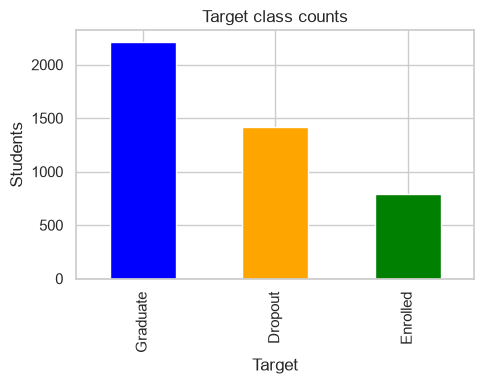

In [3]:
counts = df[TARGET_COL].value_counts()
proportions = df[TARGET_COL].value_counts(normalize=True).round(3)
print(proportions)

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind = "bar", ax=ax, color = ["blue", "orange", "green"])
ax.set_title("Target class counts")
ax.set_ylabel("Students")
plt.tight_layout()
plt.show()

# notice the imbalance in the target classes
# 50% Graduate, 32% Dropout, 18% Enrolled
# this is why the modeling step uses class_weight='balanced' 
# otherwise, a model could hit about 70% accuracy by predicting the majority class (Graduate)

## 3. Exploratory Data Analysis
### 3.1 Key numeric variables vs. Target

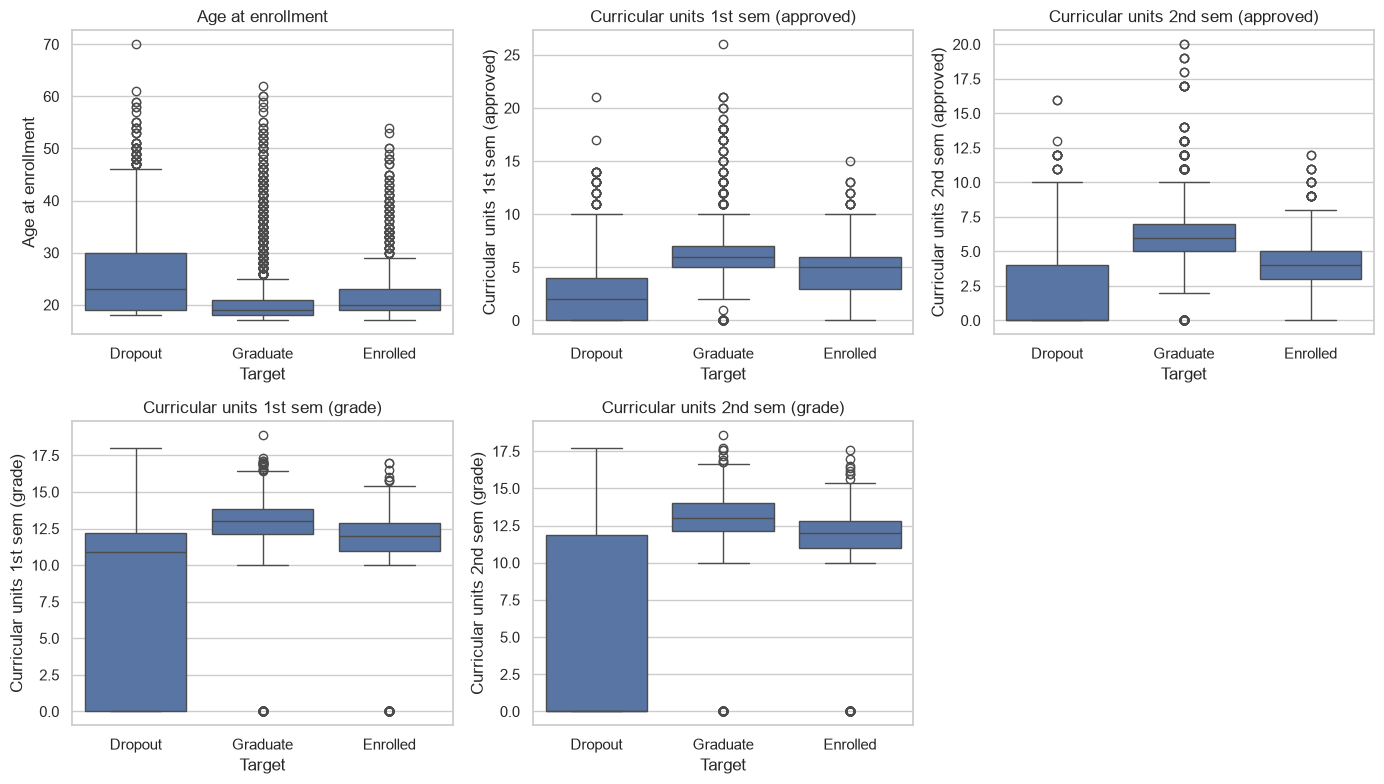

In [4]:
key_numeric_cols = [
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
for ax, col in zip(axes.flat, key_numeric_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=ax)
    ax.set_title(col)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()



### 3.2 Key categorical/binary variables vs. Target

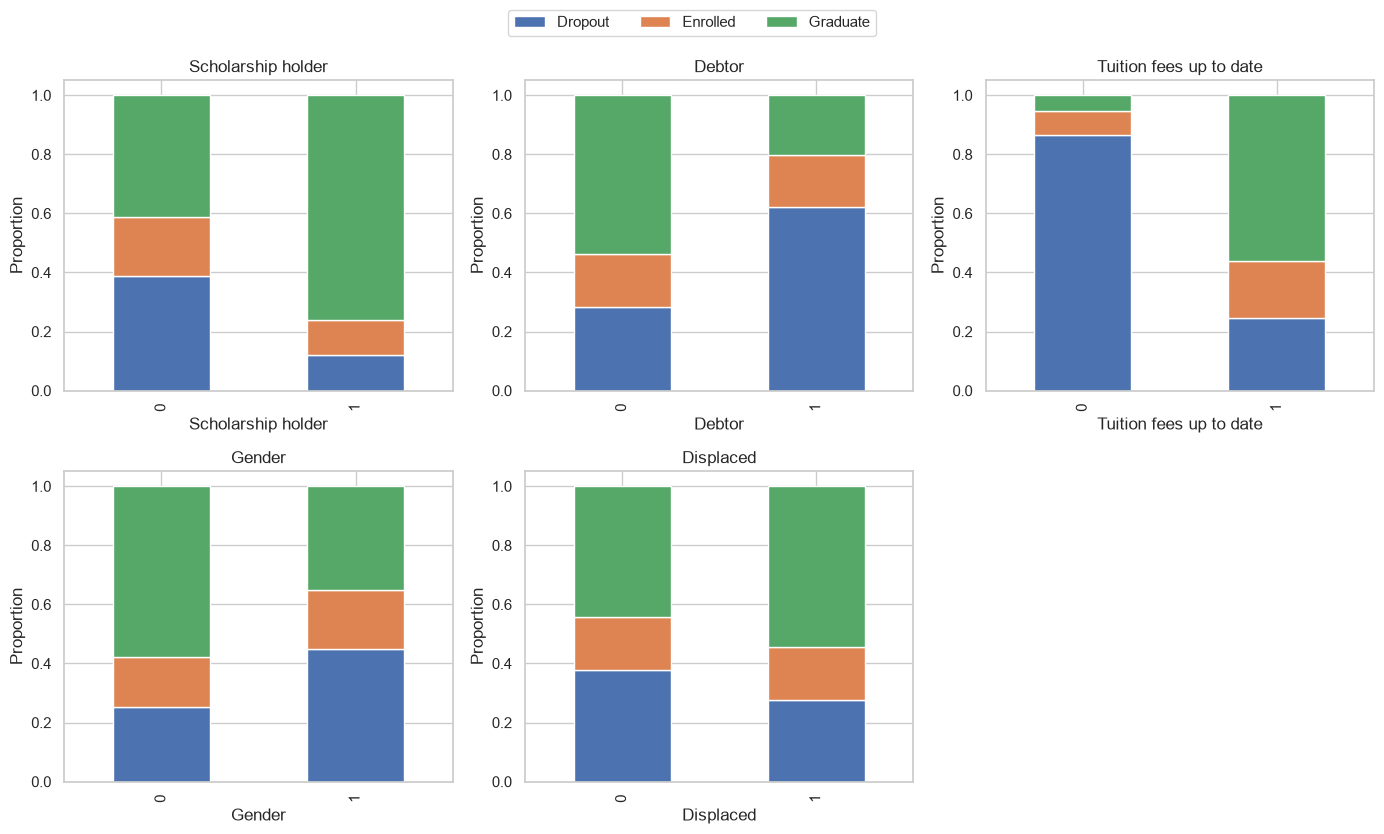

In [5]:
key_categorical_cols = ["Scholarship holder", "Debtor", "Tuition fees up to date", "Gender", "Displaced"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, key_categorical_cols):
    rates = pd.crosstab(df[col], df[TARGET_COL], normalize="index")
    rates.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(col)
    ax.set_ylabel("Proportion")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05))
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()


### 3.3 Correlation and Collinearity
#### 3.3.1 Collinearity check: parental variables

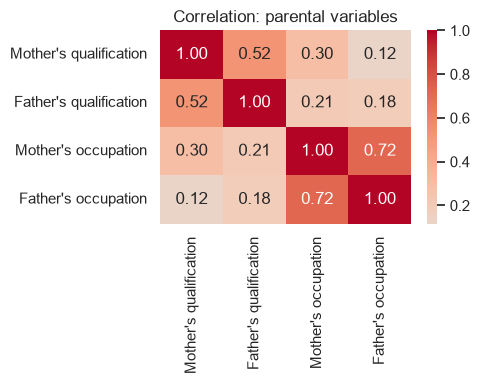

In [6]:
parent_education_cols = ["Mother's qualification", "Father's qualification",
               "Mother's occupation", "Father's occupation"]

corr = df[parent_education_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation: parental variables")
plt.tight_layout()
plt.show()


#### 3.3.2 Full numeric correlation heatmap

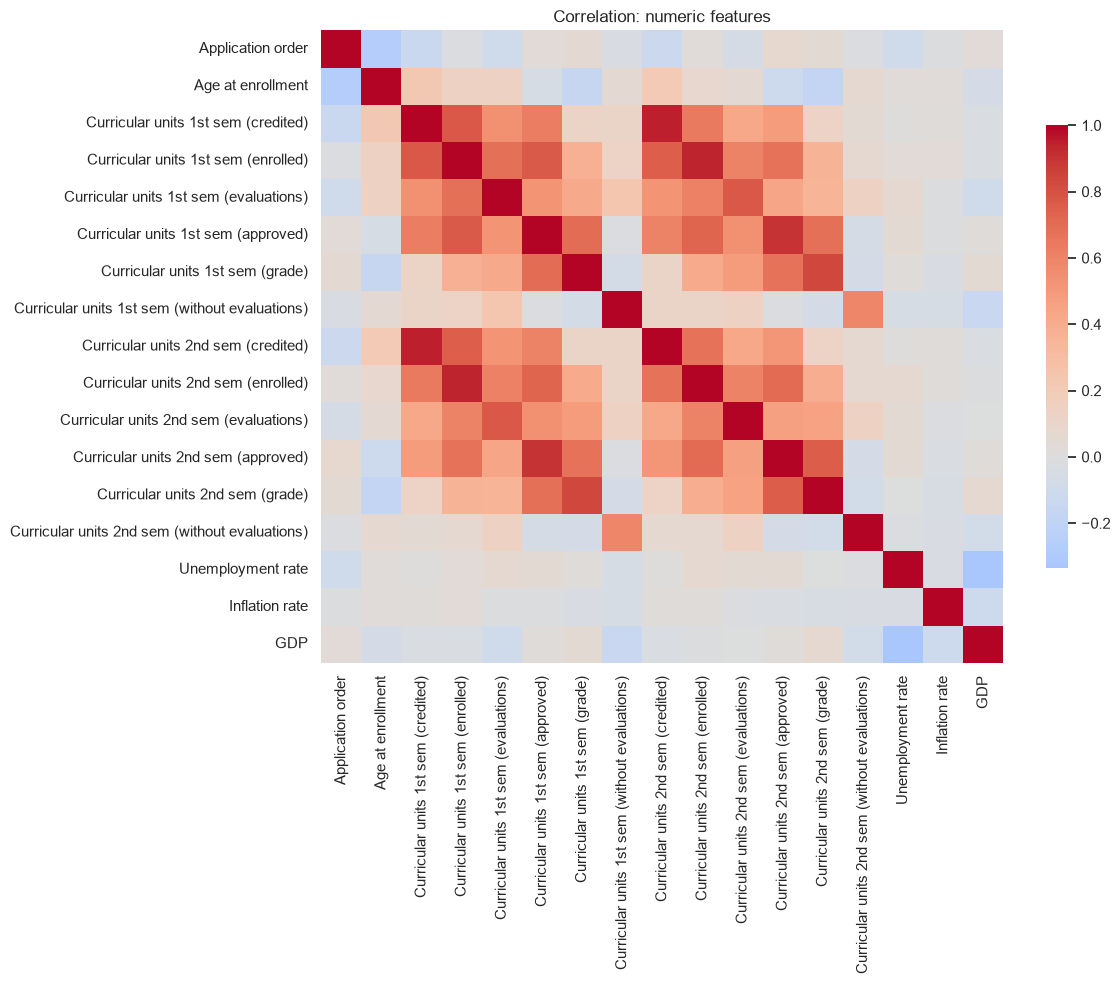

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[NUMERIC_COLS].corr(), cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlation: numeric features")
plt.tight_layout()
plt.show()

### 3.4 Categorical Feature Cardinality

Father's occupation       46
Father's qualification    34
Mother's occupation       32
Mother's qualification    29
Nacionality               21
Application mode          18
Previous qualification    17
Course                    17
Marital status             6
dtype: int64

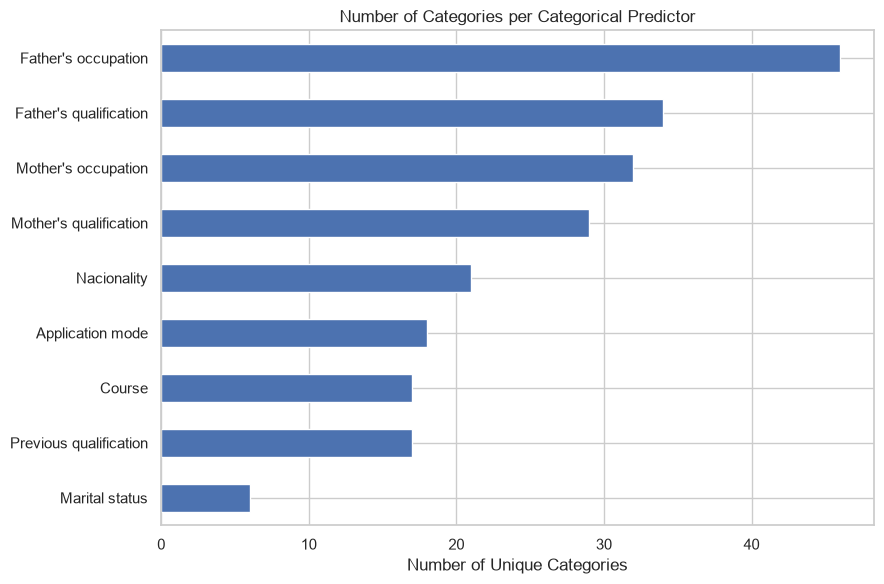

In [8]:
# Categorical Feature Cardinality

category_cardinality = (
    df[CATEGORICAL_COLS]
    .nunique()
    .sort_values(ascending=False)
)

display(category_cardinality)

fig, ax = plt.subplots(figsize=(9, 6))

category_cardinality.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title("Number of Categories per Categorical Predictor")
ax.set_xlabel("Number of Unique Categories")

plt.tight_layout()
plt.show()

### 3.5 Structural Zero Analysis

Students with Semester 1 grade = 0: 718
Proportion with Semester 1 grade = 0: 16.230%


Target,Dropout,Enrolled,Graduate
Sem1 grade zero,,,
0,0.230,0.195,0.575
1,0.794,0.099,0.107


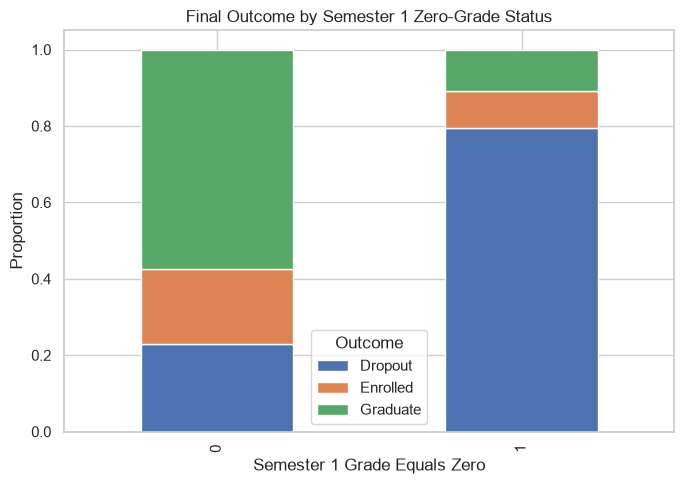

In [9]:
# Structural Zeros in Semester 1 Grades

sem1_grade_col = "Curricular units 1st sem (grade)"

n_zero = (df[sem1_grade_col] == 0).sum()
prop_zero = (df[sem1_grade_col] == 0).mean()

print(f"Students with Semester 1 grade = 0: {n_zero}")
print(f"Proportion with Semester 1 grade = 0: {prop_zero:.3%}")

# Temporary indicator for EDA
df["Sem1 grade zero"] = (
    df[sem1_grade_col] == 0
).astype(int)

zero_grade_outcomes = pd.crosstab(
    df["Sem1 grade zero"],
    df[TARGET_COL],
    normalize="index"
)

display(zero_grade_outcomes.round(3))

fig, ax = plt.subplots(figsize=(7, 5))

zero_grade_outcomes.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Final Outcome by Semester 1 Zero-Grade Status")
ax.set_xlabel("Semester 1 Grade Equals Zero")
ax.set_ylabel("Proportion")

plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

## 4. First Logistic Regression Baseline

### 4.1 Model Fit

In [10]:
X_train, X_test, y_train, y_test = stratified_split(df)

print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))

pipe = build_logreg_pipeline(get_logistic_regression())
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred))

Train class balance:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Test class balance:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64
              precision    recall  f1-score   support

     Dropout       0.81      0.69      0.75       284
    Enrolled       0.41      0.62      0.49       159
    Graduate       0.86      0.78      0.82       442

    accuracy                           0.72       885
   macro avg       0.69      0.70      0.69       885
weighted avg       0.76      0.72      0.74       885



### 4.2 Confusion Matrix Analysis

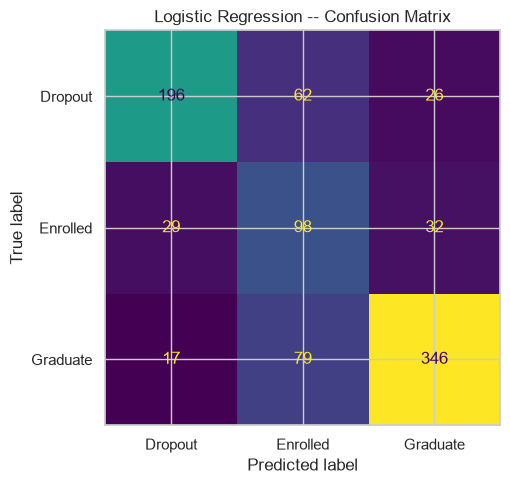

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Logistic Regression -- Confusion Matrix")
plt.tight_layout()
plt.show()

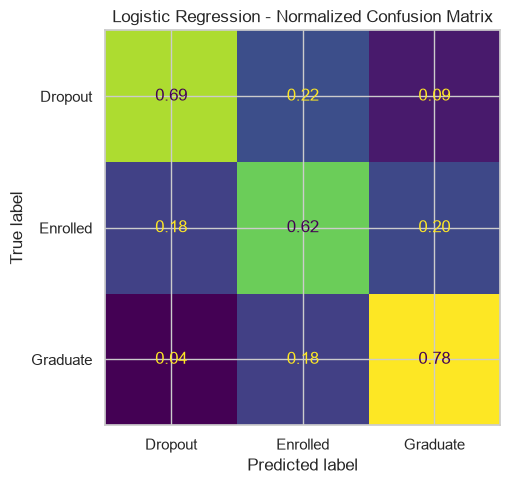

In [12]:
# Normalized Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",      # Each row sums to 1
    values_format=".2f",
    colorbar=False,
    ax=ax
)

ax.set_title("Logistic Regression - Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

### 4.3 Overall Performance Metrics

In [13]:
# Logistic Regression Metric Summary

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score
)

logreg_accuracy = accuracy_score(y_test, y_pred)

logreg_macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

logreg_weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

logreg_macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy:     {logreg_accuracy:.3f}")
print(f"Macro F1:     {logreg_macro_f1:.3f}")
print(f"Weighted F1:  {logreg_weighted_f1:.3f}")
print(f"Macro Recall: {logreg_macro_recall:.3f}")


Accuracy:     0.723
Macro F1:     0.685
Weighted F1:  0.736
Macro Recall: 0.696


### 4.4 Logistic Regression Coefficient Interpretation

In [14]:
# Extract the fitted preprocessing object and logistic model
preprocessor = pipe.named_steps["preprocess"]
logreg_model = pipe.named_steps["model"]

# Names of predictors after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Each row corresponds to one target class
coef_df = pd.DataFrame(
    logreg_model.coef_,
    columns=feature_names,
    index=logreg_model.classes_
)

coef_df.head()

,num__Application order,num__Age at enrollment,num__Curricular units 1st sem (credited),num__Curricular units 1st sem (enrolled),num__Curricular units 1st sem (evaluations),num__Curricular units 1st sem (approved),num__Curricular units 1st sem (grade),num__Curricular units 1st sem (without evaluations),num__Curricular units 2nd sem (credited),num__Curricular units 2nd sem (enrolled),...,cat__Father's occupation_45,cat__Father's occupation_46,bin__Daytime/evening attendance,bin__Displaced,bin__Educational special needs,bin__Debtor,bin__Tuition fees up to date,bin__Gender,bin__Scholarship holder,bin__International
Dropout,0.129472,0.112860,0.153486,0.303383,-0.037158,-0.863032,0.073770,-0.081049,0.300656,0.954889,...,0.046976,-0.005209,0.152739,0.226651,0.088649,0.425820,-1.821728,0.215390,-0.180744,-0.184959
Enrolled,-0.122893,-0.004446,-0.031702,0.257466,0.205088,-0.433444,-0.099281,0.059075,-0.233649,0.212911,...,-0.428114,-0.195000,-0.061851,-0.107501,0.015132,0.281862,0.248170,-0.089458,-0.291453,0.183232
Graduate,-0.006579,-0.108414,-0.121784,-0.560849,-0.167930,1.296476,0.025510,0.021974,-0.067007,-1.167800,...,0.381138,0.200209,-0.090888,-0.119150,-0.103781,-0.707682,1.573558,-0.125933,0.472197,0.001728


In [15]:
# Look specifically at predictors associated with Dropout
dropout_coef = coef_df.loc["Dropout"].sort_values()

print("Most negative coefficients:")
display(dropout_coef.head(10))

print("\nMost positive coefficients:")
display(dropout_coef.tail(10))

Most negative coefficients:


bin__Tuition fees up to date               -1.821728
num__Curricular units 2nd sem (approved)   -1.657516
cat__Mother's occupation_29                -1.240486
cat__Nacionality_11                        -0.980760
num__Curricular units 1st sem (approved)   -0.863032
cat__Course_2                              -0.810490
cat__Mother's qualification_4              -0.800037
cat__Application mode_6                    -0.784538
cat__Father's occupation_35                -0.639681
cat__Application mode_17                   -0.614982
Name: Dropout, dtype: float64


Most positive coefficients:


cat__Mother's occupation_9                  0.689231
cat__Father's qualification_30              0.734439
cat__Previous qualification_4               0.743423
cat__Previous qualification_2               0.774903
cat__Course_16                              0.840396
cat__Course_8                               0.853895
cat__Mother's occupation_12                 0.873045
num__Curricular units 2nd sem (enrolled)    0.954889
cat__Father's occupation_12                 1.167572
cat__Mother's occupation_1                  1.254176
Name: Dropout, dtype: float64

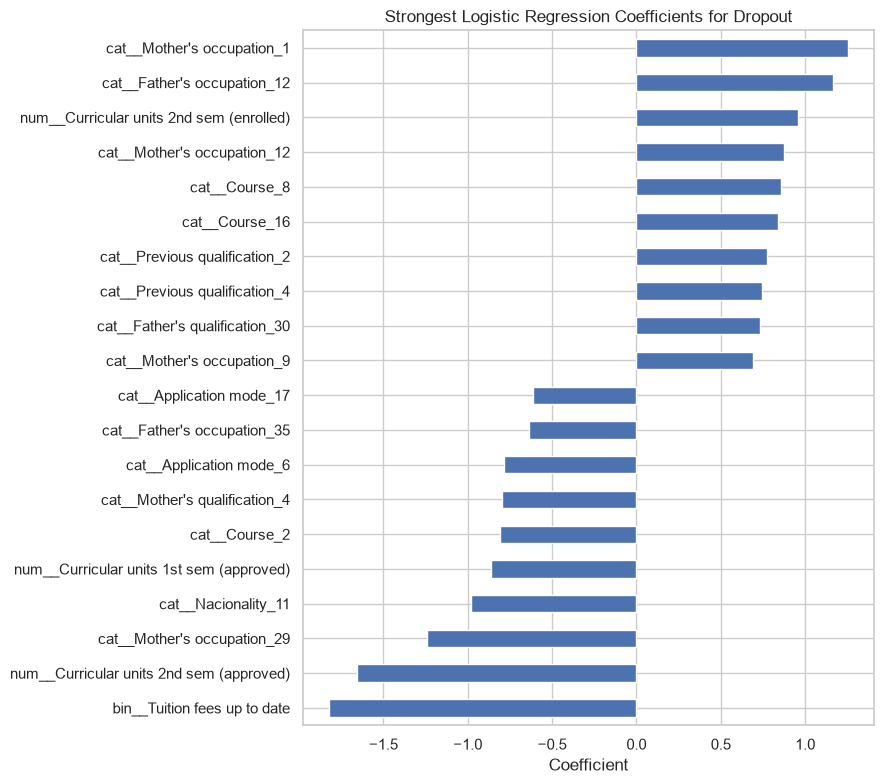

In [16]:
# Select the strongest coefficients in either direction
top_dropout_coef = pd.concat([
    dropout_coef.head(10),
    dropout_coef.tail(10)
]).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))

top_dropout_coef.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Strongest Logistic Regression Coefficients for Dropout")
ax.set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

## 5. Feature Availability Analysis

The project's main question asks whether final academic outcome can be
predicted using information available at different stages of a student's
academic progression.

We compare three predictor sets:

- **Day 1:** information available before first-semester performance
- **After Semester 1:** includes first-semester academic performance
- **Full Data:** includes first- and second-semester academic performance

### 5.1 Define Feature Sets

In [17]:
# Feature Availability Scenarios
# Find every Semester 1 predictor
sem1_cols = [
    col for col in df.columns
    if "Curricular units 1st sem" in col
]

# Find every Semester 2 predictor
sem2_cols = [
    col for col in df.columns
    if "Curricular units 2nd sem" in col
]

print("Semester 1 variables:")
for col in sem1_cols:
    print("  ", col)

print("\nSemester 2 variables:")
for col in sem2_cols:
    print("  ", col)

# Remove our temporary EDA variable if it exists
extra_cols = ["Sem1 grade zero"]

# Day 1: No Semester 1 or Semester 2 performance has happened yet.
day1_cols = [
    col for col in df.columns
    if col not in (
        sem1_cols
        + sem2_cols
        + [TARGET_COL]
        + extra_cols
    )
]

# After Semester 1: Semester 1 information is now available, but Semester 2 information is still unavailable.
after_sem1_cols = [
    col for col in df.columns
    if col not in (
        sem2_cols
        + [TARGET_COL]
        + extra_cols
    )
]

# Full information
full_cols = [
    col for col in df.columns
    if col not in (
        [TARGET_COL]
        + extra_cols
    )
]

print("Number of Day-1 predictors:", len(day1_cols))
print("Number after Semester 1:", len(after_sem1_cols))
print("Number in full model:", len(full_cols))

Semester 1 variables:
   Curricular units 1st sem (credited)
   Curricular units 1st sem (enrolled)
   Curricular units 1st sem (evaluations)
   Curricular units 1st sem (approved)
   Curricular units 1st sem (grade)
   Curricular units 1st sem (without evaluations)

Semester 2 variables:
   Curricular units 2nd sem (credited)
   Curricular units 2nd sem (enrolled)
   Curricular units 2nd sem (evaluations)
   Curricular units 2nd sem (approved)
   Curricular units 2nd sem (grade)
   Curricular units 2nd sem (without evaluations)
Number of Day-1 predictors: 22
Number after Semester 1: 28
Number in full model: 34


### 5.2 Logistic regression comparison

In [18]:
from src.preprocessing import build_model_pipeline
from sklearn.model_selection import train_test_split

# Compare Logistic Regression Across Feature Availability
def evaluate_logistic_feature_set(
    df,
    feature_cols,
    feature_set_name
):
    """
    Fit balanced logistic regression using one set
    of available predictors and return performance metrics.
    """

    X = df[feature_cols]
    y = df[TARGET_COL]

    # Same 80/20 stratified split for every scenario
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = (
        train_test_split(
            X,
            y,
            test_size=0.20,
            stratify=y,
            random_state=42
        )
    )

    # Reuse the team's model definition
    model = get_logistic_regression(
        random_state=42
    )

    # Logistic regression benefits from scaling numeric variables
    model_pipe = build_model_pipeline(
        model=model,
        feature_cols=feature_cols,
        scale_numeric=True
    )

    model_pipe.fit(
        X_train_temp,
        y_train_temp
    )

    pred = model_pipe.predict(
        X_test_temp
    )

    return {
        "Feature Set": feature_set_name,

        "Accuracy": accuracy_score(
            y_test_temp,
            pred
        ),

        "Macro F1": f1_score(
            y_test_temp,
            pred,
            average="macro"
        ),

        "Dropout Recall": recall_score(
            y_test_temp,
            pred,
            labels=["Dropout"],
            average=None
        )[0],

        "Enrolled Recall": recall_score(
            y_test_temp,
            pred,
            labels=["Enrolled"],
            average=None
        )[0],

        "Graduate Recall": recall_score(
            y_test_temp,
            pred,
            labels=["Graduate"],
            average=None
        )[0]
    }

feature_results = [
    evaluate_logistic_feature_set(
        df,
        day1_cols,
        "Day 1"
    ),

    evaluate_logistic_feature_set(
        df,
        after_sem1_cols,
        "After Semester 1"
    ),

    evaluate_logistic_feature_set(
        df,
        full_cols,
        "Full Data"
    )
]

feature_results_df = pd.DataFrame(
    feature_results
)

display(
    feature_results_df.round(3)
)

,Feature Set,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall
0,Day 1,0.567,0.541,0.585,0.484,0.586
1,After Semester 1,0.688,0.648,0.673,0.547,0.749
2,Full Data,0.723,0.685,0.690,0.616,0.783


### 5.3 Visualize Feature-Availability Results

#### 5.3.1 Macro F1 and accuracy

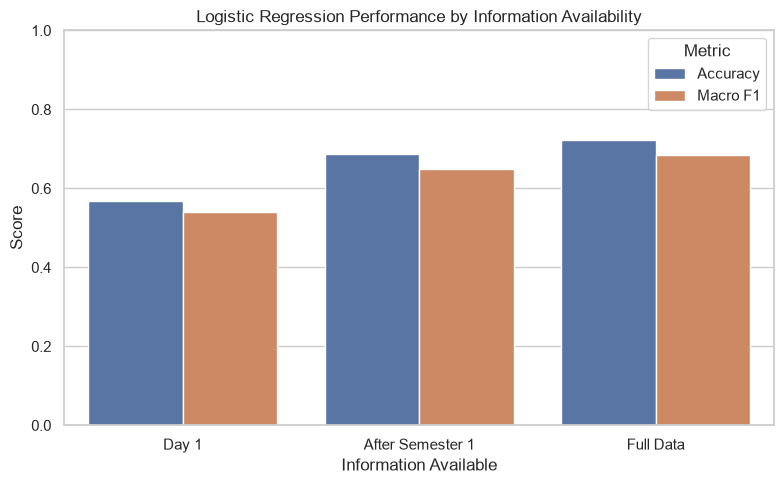

In [21]:
# Convert the table to long format so Accuracy and Macro F1 can be displayed next to one another.
feature_performance_long = feature_results_df.melt(
    id_vars="Feature Set",
    value_vars=["Accuracy", "Macro F1"],
    var_name="Metric",
    value_name="Score"
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=feature_performance_long,
    x="Feature Set",
    y="Score",
    hue="Metric",
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_title(
    "Logistic Regression Performance by Information Availability"
)
ax.set_xlabel("Information Available")
ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

#### 5.3.2 Recall for each outcome

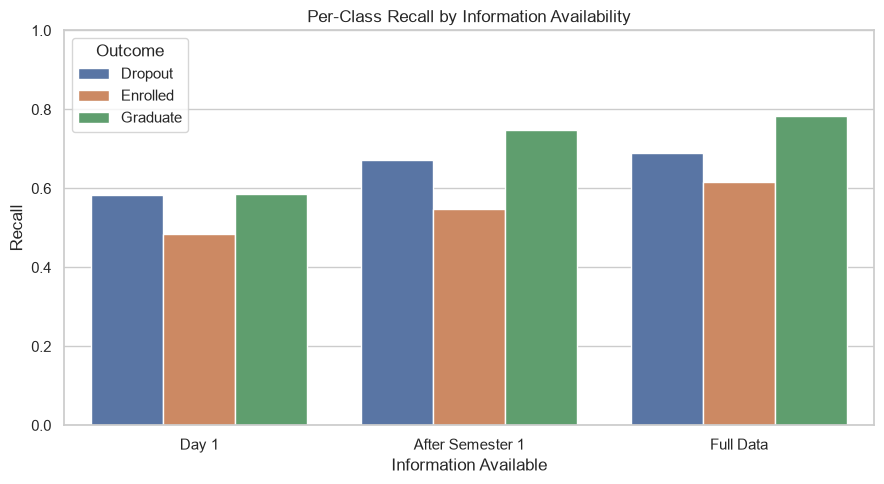

In [22]:
# Reshape the three recall columns into long format.
feature_recall_long = feature_results_df.melt(
    id_vars="Feature Set",
    value_vars=[
        "Dropout Recall",
        "Enrolled Recall",
        "Graduate Recall"
    ],
    var_name="Outcome",
    value_name="Recall"
)

# Clean up labels for plotting.
feature_recall_long["Outcome"] = (
    feature_recall_long["Outcome"]
    .str.replace(" Recall", "", regex=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=feature_recall_long,
    x="Feature Set",
    y="Recall",
    hue="Outcome",
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_title(
    "Per-Class Recall by Information Availability"
)
ax.set_xlabel("Information Available")
ax.set_ylabel("Recall")

plt.tight_layout()
plt.show()

##  6. Random Forest

### 6.1 Random Forest across all three feature sets

In [38]:
# Random Forest Across Feature Sets
def evaluate_rf_feature_set(df, feature_cols, feature_set_name, return_model=False):
    """
    Fit Random Forest using one set of predictors and return
    overall and class-specific performance metrics.

    If return_model=True, also return the fitted pipeline.
    """

    X = df[feature_cols]
    y = df[TARGET_COL]

    # Same stratified 80/20 split strategy for every feature set
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # Use the team's Random Forest definition
    model = get_random_forest(random_state=42)

    # Random Forest does not need numeric scaling
    model_pipe = build_model_pipeline(
        model=model,
        feature_cols=feature_cols,
        scale_numeric=False
    )

    # Fit the full preprocessing + Random Forest pipeline
    model_pipe.fit(
        X_train_temp,
        y_train_temp
    )

    # Make predictions on the held-out test set
    predictions = model_pipe.predict(
        X_test_temp
    )

    # Store all performance measures
    results = {
        "Feature Set": feature_set_name,

        "Accuracy": accuracy_score(
            y_test_temp,
            predictions
        ),

        "Macro F1": f1_score(
            y_test_temp,
            predictions,
            average="macro"
        ),

        "Dropout Recall": recall_score(
            y_test_temp,
            predictions,
            labels=["Dropout"],
            average=None
        )[0],

        "Enrolled Recall": recall_score(
            y_test_temp,
            predictions,
            labels=["Enrolled"],
            average=None
        )[0],

        "Graduate Recall": recall_score(
            y_test_temp,
            predictions,
            labels=["Graduate"],
            average=None
        )[0]
    }

    # Usually we only need the metrics, but we also want the fitted pipeline so we can examine feature importance later.
    if return_model:
        return results, model_pipe

    return results

# Day-1 Random Forest
rf_day1_results = evaluate_rf_feature_set(
    df,
    day1_cols,
    "Day 1"
)

# After-Semester-1 Random Forest
rf_after_sem1_results = evaluate_rf_feature_set(
    df,
    after_sem1_cols,
    "After Semester 1"
)

# Full-data Random Forest
# Save BOTH the results and the fitted pipeline.
rf_full_results, rf_full_pipe = evaluate_rf_feature_set(
    df,
    full_cols,
    "Full Data",
    return_model=True
)

# Combine results into one table
rf_feature_results = [
    rf_day1_results,
    rf_after_sem1_results,
    rf_full_results
]

rf_feature_results_df = pd.DataFrame(
    rf_feature_results
)

display(
    rf_feature_results_df.round(3)
)

,Feature Set,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall
0,Day 1,0.610,0.543,0.630,0.283,0.715
1,After Semester 1,0.730,0.667,0.704,0.434,0.853
2,Full Data,0.768,0.713,0.729,0.516,0.885


### 6.2 RF visualization

#### 6.2.1 Macro F1 and accuracy

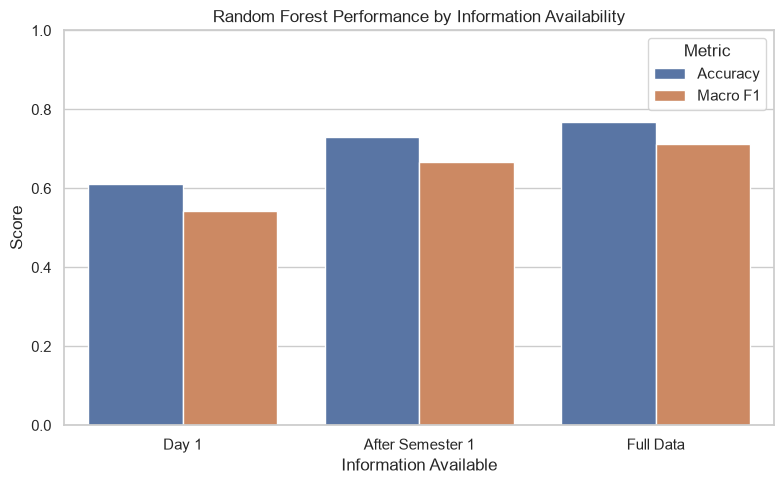

In [35]:
# 6.2 Random Forest Feature Availability Visualization

rf_performance_long = rf_feature_results_df.melt(
    id_vars="Feature Set",
    value_vars=["Accuracy", "Macro F1"],
    var_name="Metric",
    value_name="Score"
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=rf_performance_long,
    x="Feature Set",
    y="Score",
    hue="Metric",
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_title(
    "Random Forest Performance by Information Availability"
)
ax.set_xlabel("Information Available")
ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

#### 6.2.2 Per-class recall

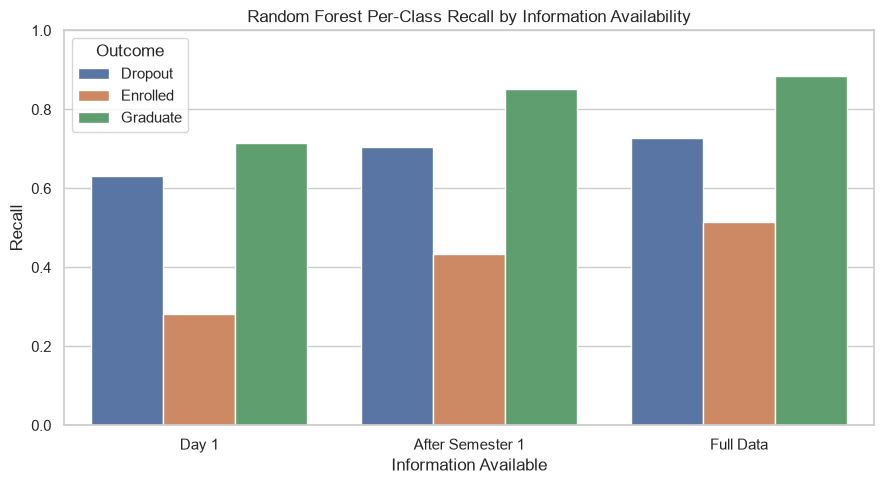

In [36]:
rf_recall_long = rf_feature_results_df.melt(
    id_vars="Feature Set",
    value_vars=[
        "Dropout Recall",
        "Enrolled Recall",
        "Graduate Recall"
    ],
    var_name="Outcome",
    value_name="Recall"
)

rf_recall_long["Outcome"] = (
    rf_recall_long["Outcome"]
    .str.replace(" Recall", "", regex=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=rf_recall_long,
    x="Feature Set",
    y="Recall",
    hue="Outcome",
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_title(
    "Random Forest Per-Class Recall by Information Availability"
)
ax.set_xlabel("Information Available")
ax.set_ylabel("Recall")

plt.tight_layout()
plt.show()

### 6.3 Random Forest Feature Importance

In [39]:
# Random Forest Feature Importance
# Reuse the fitted full-data Random Forest from Section 6.1
rf_preprocessor = rf_full_pipe.named_steps["preprocess"]
rf_model = rf_full_pipe.named_steps["model"]

# Get predictor names after preprocessing
rf_feature_names = rf_preprocessor.get_feature_names_out()

# Match each predictor with its Random Forest importance
rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model.feature_importances_
})

# Remove preprocessing prefixes for cleaner display
rf_importance_df["Feature"] = (
    rf_importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("bin__", "", regex=False)
)

# Sort from most important to least important
rf_importance_df = (
    rf_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_importance_df.head(20))

,Feature,Importance
0,Curricular units 2nd sem (approved),0.093843
1,Curricular units 2nd sem (grade),0.081179
2,Curricular units 1st sem (approved),0.066090
3,Curricular units 1st sem (grade),0.065343
4,Curricular units 2nd sem (evaluations),0.043755
5,Curricular units 1st sem (evaluations),0.041712
6,Age at enrollment,0.038257
7,Tuition fees up to date,0.033365
8,GDP,0.025829
9,Unemployment rate,0.025662


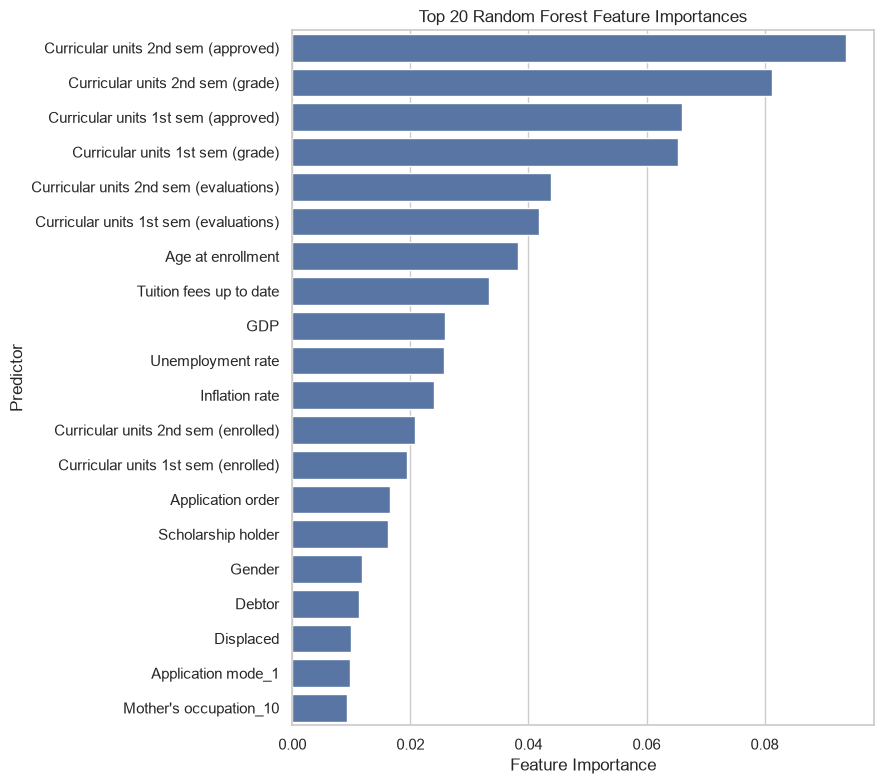

In [40]:
top_rf_features = rf_importance_df.head(20)

fig, ax = plt.subplots(figsize=(9, 8))

sns.barplot(
    data=top_rf_features,
    x="Importance",
    y="Feature",
    ax=ax
)

ax.set_title("Top 20 Random Forest Feature Importances")
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Predictor")

plt.tight_layout()
plt.show()

According to the fitted Random Forest, these variables contributed most strongly to the model's tree splits.

## 7. Model Comparison

### 7.1 Comparison

In [41]:
# 7.1 Logistic Regression vs Random Forest
# Across Feature Availability

logreg_compare = feature_results_df.copy()
logreg_compare["Model"] = "Logistic Regression"

rf_compare = rf_feature_results_df.copy()
rf_compare["Model"] = "Random Forest"

all_model_results = pd.concat(
    [logreg_compare, rf_compare],
    ignore_index=True
)

display(
    all_model_results.round(3)
)

,Feature Set,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall,Model
0,Day 1,0.567,0.541,0.585,0.484,0.586,Logistic Regression
1,After Semester 1,0.688,0.648,0.673,0.547,0.749,Logistic Regression
2,Full Data,0.723,0.685,0.690,0.616,0.783,Logistic Regression
3,Day 1,0.610,0.543,0.630,0.283,0.715,Random Forest
4,After Semester 1,0.730,0.667,0.704,0.434,0.853,Random Forest
5,Full Data,0.768,0.713,0.729,0.516,0.885,Random Forest


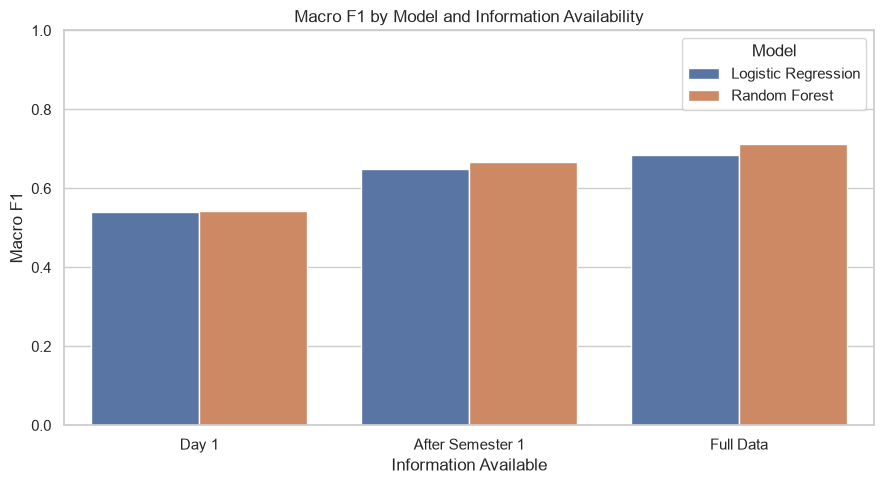

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=all_model_results,
    x="Feature Set",
    y="Macro F1",
    hue="Model",
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_title(
    "Macro F1 by Model and Information Availability"
)
ax.set_xlabel("Information Available")
ax.set_ylabel("Macro F1")

plt.tight_layout()
plt.show()

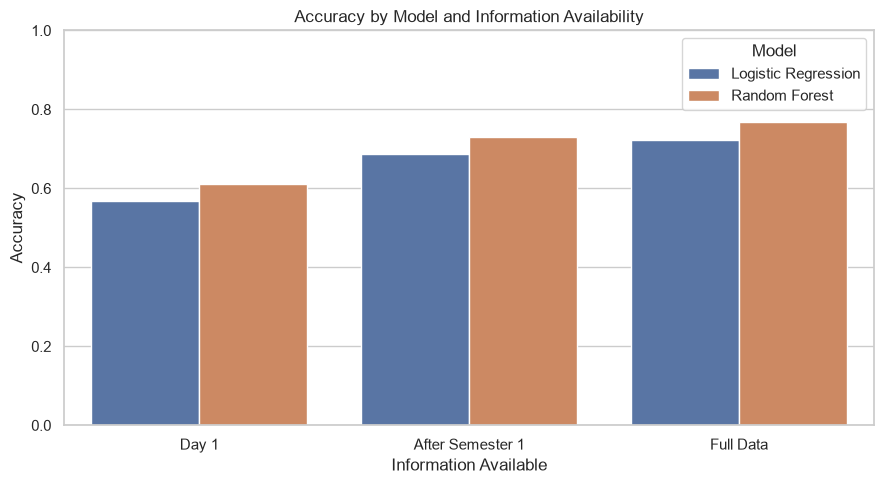

In [43]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=all_model_results,
    x="Feature Set",
    y="Accuracy",
    hue="Model",
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_title(
    "Accuracy by Model and Information Availability"
)
ax.set_xlabel("Information Available")
ax.set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

### 7.2 Per-Class Recall

In [46]:

# Per-Class Recall Comparison


recall_long = all_model_results.melt(
    id_vars=[
        "Feature Set",
        "Model"
    ],
    value_vars=[
        "Dropout Recall",
        "Enrolled Recall",
        "Graduate Recall"
    ],
    var_name="Outcome",
    value_name="Recall"
)

# Clean the labels
recall_long["Outcome"] = (
    recall_long["Outcome"]
    .str.replace(" Recall", "", regex=False)
)

display(recall_long.head())

,Feature Set,Model,Outcome,Recall
0,Day 1,Logistic Regression,Dropout,0.584507
1,After Semester 1,Logistic Regression,Dropout,0.672535
2,Full Data,Logistic Regression,Dropout,0.690141
3,Day 1,Random Forest,Dropout,0.630282
4,After Semester 1,Random Forest,Dropout,0.704225


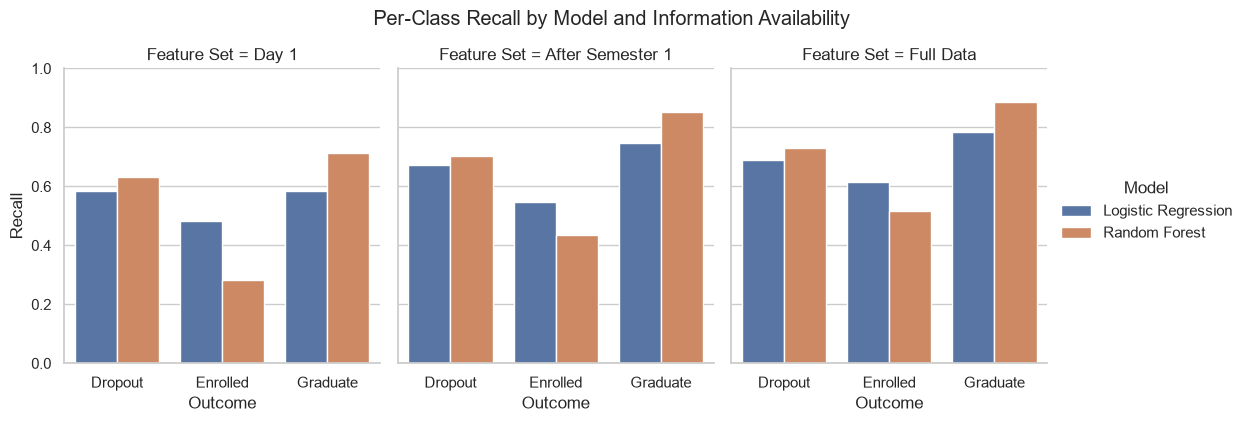

In [45]:
g = sns.catplot(
    data=recall_long,
    x="Outcome",
    y="Recall",
    hue="Model",
    col="Feature Set",
    kind="bar",
    height=4,
    aspect=0.9
)

g.set(ylim=(0, 1))
g.set_axis_labels("Outcome", "Recall")

g.fig.suptitle(
    "Per-Class Recall by Model and Information Availability",
    y=1.05
)

plt.show()

In [29]:
classes = [
    "Dropout",
    "Enrolled",
    "Graduate"
]

# Recall for each class from Logistic Regression.
logreg_class_recall = recall_score(
    y_test,
    y_pred,
    labels=classes,
    average=None
)

# Recall for each class from Random Forest.
rf_class_recall = recall_score(
    y_test_rf,
    y_pred_rf,
    labels=classes,
    average=None
)

recall_comparison = pd.DataFrame({
    "Class": classes,
    "Logistic Regression": logreg_class_recall,
    "Random Forest": rf_class_recall
})

display(
    recall_comparison.round(3)
)

,Class,Logistic Regression,Random Forest
0,Dropout,0.690,0.729
1,Enrolled,0.616,0.516
2,Graduate,0.783,0.885


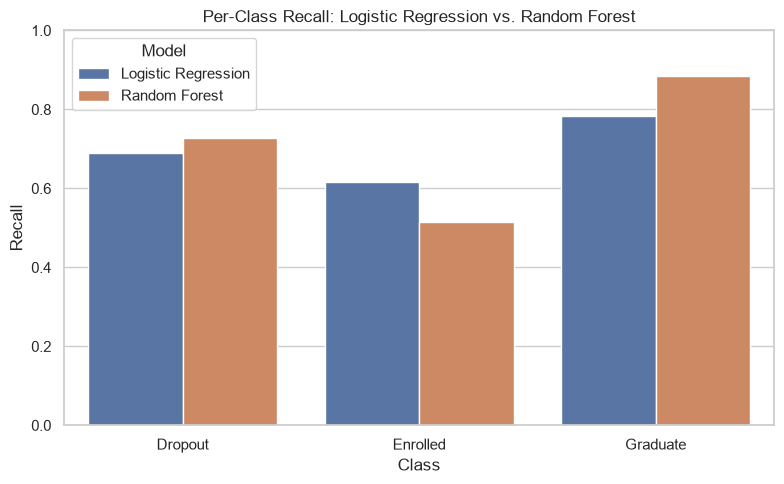

In [30]:
recall_comparison_long = recall_comparison.melt(
    id_vars="Class",
    var_name="Model",
    value_name="Recall"
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=recall_comparison_long,
    x="Class",
    y="Recall",
    hue="Model",
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_title("Per-Class Recall: Logistic Regression vs. Random Forest")

plt.tight_layout()
plt.show()

### 7.3 Stratified 5-Fold Cross-Validation

In [31]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

# 7.3 Stratified 5-Fold Cross-Validation

# Stratified folds maintain approximately the same outcome proportions in each fold.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate several metrics during each fold.
scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "macro_recall": "recall_macro"
}

X_cv = df[full_cols]
y_cv = df[TARGET_COL]

# Logistic Regression Cross-Validation
logreg_cv_pipe = build_model_pipeline(
    model=get_logistic_regression(random_state=42),
    feature_cols=full_cols,
    scale_numeric=True
)

logreg_cv_results = cross_validate(
    logreg_cv_pipe,
    X_cv,
    y_cv,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# Random Forest Cross-Validation
rf_cv_pipe = build_model_pipeline(
    model=get_random_forest(random_state=42),
    feature_cols=full_cols,
    scale_numeric=False
)

rf_cv_results = cross_validate(
    rf_cv_pipe,
    X_cv,
    y_cv,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Mean Accuracy": [
        logreg_cv_results["test_accuracy"].mean(),
        rf_cv_results["test_accuracy"].mean()
    ],

    "SD Accuracy": [
        logreg_cv_results["test_accuracy"].std(),
        rf_cv_results["test_accuracy"].std()
    ],

    "Mean Macro F1": [
        logreg_cv_results["test_macro_f1"].mean(),
        rf_cv_results["test_macro_f1"].mean()
    ],

    "SD Macro F1": [
        logreg_cv_results["test_macro_f1"].std(),
        rf_cv_results["test_macro_f1"].std()
    ],

    "Mean Macro Recall": [
        logreg_cv_results["test_macro_recall"].mean(),
        rf_cv_results["test_macro_recall"].mean()
    ],

    "SD Macro Recall": [
        logreg_cv_results["test_macro_recall"].std(),
        rf_cv_results["test_macro_recall"].std()
    ]
})

display(
    cv_comparison.round(3)
)

,Model,Mean Accuracy,SD Accuracy,Mean Macro F1,SD Macro F1,Mean Macro Recall,SD Macro Recall
0,Logistic Regression,0.747,0.013,0.706,0.012,0.714,0.012
1,Random Forest,0.768,0.008,0.710,0.007,0.705,0.006


In [32]:
for _, row in cv_comparison.iterrows():
    print(row["Model"])

    print(
        f"  Accuracy: "
        f"{row['Mean Accuracy']:.3f} "
        f"+/- {row['SD Accuracy']:.3f}"
    )

    print(
        f"  Macro F1: "
        f"{row['Mean Macro F1']:.3f} "
        f"+/- {row['SD Macro F1']:.3f}"
    )

    print(
        f"  Macro Recall: "
        f"{row['Mean Macro Recall']:.3f} "
        f"+/- {row['SD Macro Recall']:.3f}"
    )

    print()

Logistic Regression
  Accuracy: 0.747 +/- 0.013
  Macro F1: 0.706 +/- 0.012
  Macro Recall: 0.714 +/- 0.012

Random Forest
  Accuracy: 0.768 +/- 0.008
  Macro F1: 0.710 +/- 0.007
  Macro Recall: 0.705 +/- 0.006

